In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ImportError: DLL load failed while importing _image: An Application Control policy has blocked this file.

In [3]:
df = pd.read_csv('../data/creditcard.csv')

In [4]:
df.shape

(284807, 31)

In [5]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## Amount Statistics


In [6]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [7]:
print("\nTime range:", df['Time'].min(), "to", df['Time'].max(), "seconds")
print("That's", round(df['Time'].max() / 3600, 1), "hours of data")


Time range: 0.0 to 172792.0 seconds
That's 48.0 hours of data


In [8]:
df['hour_of_day'] = (df['Time'] / 3600 % 24).astype(int)

## Hour of day feature created!

In [9]:
df['hour_of_day'].value_counts().sort_index()

hour_of_day
0      7695
1      4220
2      3328
3      3492
4      2209
5      2990
6      4101
7      7243
8     10276
9     15838
10    16598
11    16856
12    15420
13    15365
14    16570
15    16461
16    16453
17    16166
18    17039
19    15649
20    16756
21    17703
22    15441
23    10938
Name: count, dtype: int64

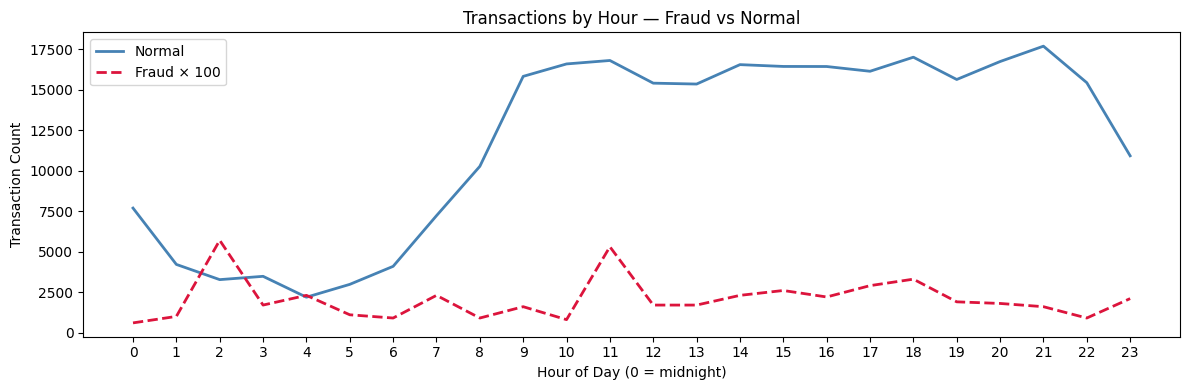

Saved hour_analysis.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

fraud    = df[df['Class'] == 1]['hour_of_day'].value_counts().sort_index()
normal   = df[df['Class'] == 0]['hour_of_day'].value_counts().sort_index()

ax.plot(normal.index, normal.values, label='Normal',
        color='steelblue', linewidth=2)
ax.plot(fraud.index,  fraud.values * 100,  label='Fraud × 100',
        color='crimson', linewidth=2, linestyle='--')
# Note: fraud multiplied ×100 just to make it visible on same scale

ax.set_xlabel('Hour of Day (0 = midnight)')
ax.set_ylabel('Transaction Count')
ax.set_title('Transactions by Hour — Fraud vs Normal')
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../reports/hour_analysis.png', dpi=150)
plt.show()
print("Saved hour_analysis.png")

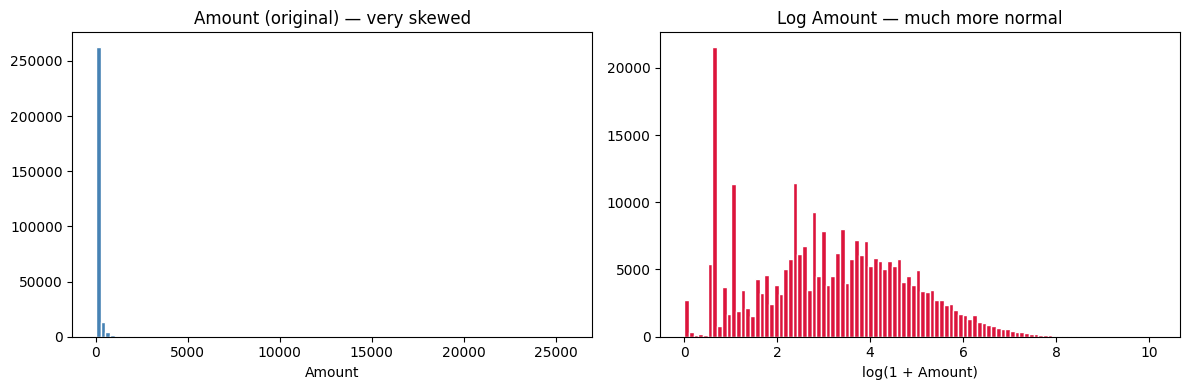

Before log — Max: 25691.16   Mean: 88.35
After  log — Max: 10.15   Mean: 3.15


In [13]:
df['log_amount'] = np.log1p(df['Amount'])

# See how it changes the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Amount'],     bins=100, color='steelblue',
             edgecolor='white')
axes[0].set_title('Amount (original) — very skewed')
axes[0].set_xlabel('Amount')

axes[1].hist(df['log_amount'], bins=100, color='crimson',
             edgecolor='white')
axes[1].set_title('Log Amount — much more normal')
axes[1].set_xlabel('log(1 + Amount)')

plt.tight_layout()
plt.savefig('../reports/log_amount.png', dpi=150)
plt.show()

print("Before log — Max:", df['Amount'].max(),
      "  Mean:", round(df['Amount'].mean(), 2))
print("After  log — Max:", round(df['log_amount'].max(), 2),
      "  Mean:", round(df['log_amount'].mean(), 2))

In [14]:
mean_amount = df['Amount'].mean()
std_amount  = df['Amount'].std()
df['amount_deviation'] = (df['Amount'] - mean_amount) / std_amount

print("Amount deviation feature created!")
print("Normal transactions — avg deviation:",
      round(df[df['Class']==0]['amount_deviation'].mean(), 4))
print("Fraud  transactions — avg deviation:",
      round(df[df['Class']==1]['amount_deviation'].mean(), 4))


Amount deviation feature created!
Normal transactions — avg deviation: -0.0002
Fraud  transactions — avg deviation: 0.1354


In [15]:
df['v1_v2_interaction'] = df['V1'] * df['V2']

print("V1×V2 interaction feature created!")
print("Sample values:", df['v1_v2_interaction'].head(5).values)
print("\nFraud    — mean V1*V2:",
      round(df[df['Class']==1]['v1_v2_interaction'].mean(), 4))
print("Normal   — mean V1*V2:",
      round(df[df['Class']==0]['v1_v2_interaction'].mean(), 4))

V1×V2 interaction feature created!
Sample values: [ 0.09896836  0.31721362  1.82041596  0.17897865 -1.01662376]

Fraud    — mean V1*V2: -41.0919
Normal   — mean V1*V2: 0.0711


In [16]:
threshold = df['Amount'].quantile(0.90)  # top 10% of amounts
print(f"High amount threshold (90th percentile): {round(threshold, 2)}")

df['high_amount_flag'] = (df['Amount'] > threshold).astype(int)
print("\nFlagged as high amount:", df['high_amount_flag'].sum())
print("% of fraud in high amount:",
      round(df[df['high_amount_flag']==1]['Class'].mean()*100, 3), "%")
print("% of fraud in normal amount:",
      round(df[df['high_amount_flag']==0]['Class'].mean()*100, 3), "%")

High amount threshold (90th percentile): 203.0

Flagged as high amount: 28458
% of fraud in high amount: 0.299 %
% of fraud in normal amount: 0.159 %


In [17]:
new_features = ['hour_of_day', 'log_amount',
                'amount_deviation', 'v1_v2_interaction',
                'high_amount_flag']

print("=== Your 5 new engineered features ===")
print(df[new_features + ['Class']].head(10))

print("\n=== Feature statistics by class ===")
for feat in new_features:
    fraud_mean  = df[df['Class']==1][feat].mean()
    normal_mean = df[df['Class']==0][feat].mean()
    print(f"{feat:25s} | Normal: {normal_mean:8.4f} | Fraud: {fraud_mean:8.4f}")

=== Your 5 new engineered features ===
   hour_of_day  log_amount  amount_deviation  v1_v2_interaction  \
0            0    5.014760          0.244964           0.098968   
1            0    1.305626         -0.342474           0.317214   
2            0    5.939276          1.160684           1.820416   
3            0    4.824306          0.140534           0.178979   
4            0    4.262539         -0.073403          -1.016624   
5            0    1.541159         -0.338556          -0.409150   
6            0    1.790091         -0.333278           0.173386   
7            0    3.732896         -0.190107          -0.913551   
8            0    4.545420          0.019392          -0.255906   
9            0    1.543298         -0.338516          -0.378716   

   high_amount_flag  Class  
0                 0      0  
1                 0      0  
2                 1      0  
3                 0      0  
4                 0      0  
5                 0      0  
6                 0 

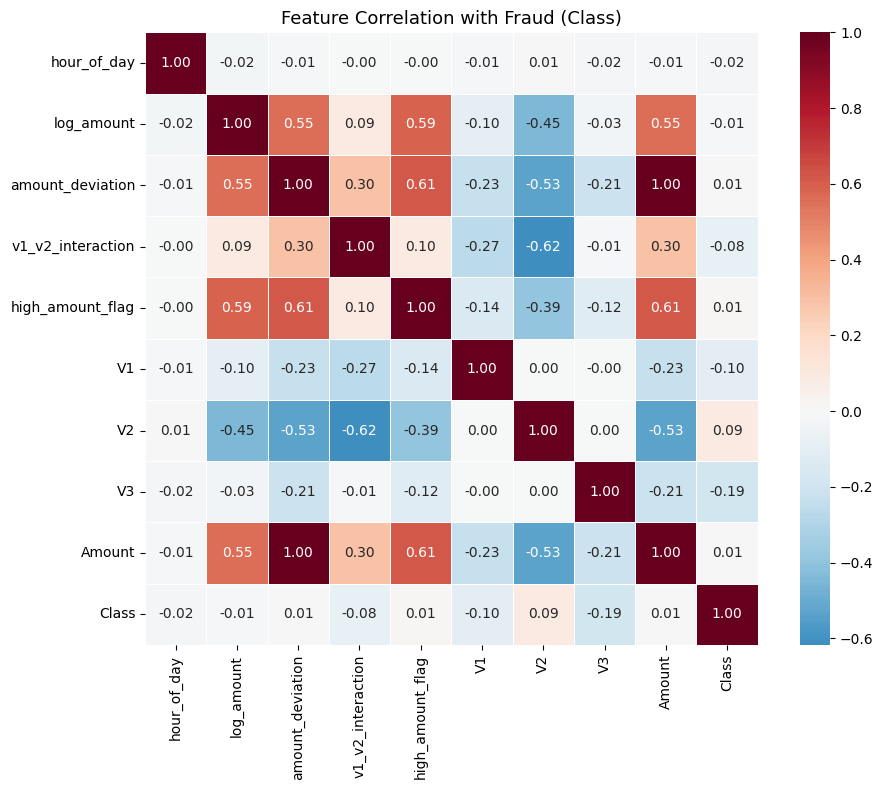

Heatmap saved!


In [18]:
cols_to_check = new_features + ['V1', 'V2', 'V3', 'Amount', 'Class']
corr = df[cols_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,          # show numbers inside boxes
    fmt='.2f',           # 2 decimal places
    cmap='RdBu_r',       # red = positive, blue = negative
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation with Fraud (Class)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved!")

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import joblib

In [ ]:
df_final = df.drop('Time', axis=1)

# Scale Amount and new numeric features
scaler = StandardScaler()
scale_cols = ['Amount', 'log_amount', 'amount_deviation', 'v1_v2_interaction']
df_final[scale_cols] = scaler.fit_transform(df_final[scale_cols])

X = df_final.drop('Class', axis=1)
y = df_final['Class']

print("Total features now:", X.shape[1])
print("Original had 29 features, now we have:", X.shape[1])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE on training only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Training:", X_train_bal.shape, "| Fraud:", y_train_bal.sum())
print("Testing: ", X_test.shape,     "| Fraud:", y_test.sum())

# Save for Phase 4
joblib.dump(X_train_bal, 'X_train.pkl')
joblib.dump(X_test,      'X_test.pkl')
joblib.dump(y_train_bal, 'y_train.pkl')
joblib.dump(y_test,      'y_test.pkl')
joblib.dump(scaler,      'scaler.pkl')  # save scaler for dashboard later

print("\nAll files saved! Phase 4 ready.")
